# **Práctica de Laboratorio Nro. 015: (Evaluación Avanzada de Modelos): Construcción de curvas ROC, cálculo del Área Bajo la Curva (métrica AUC) y validación cruzada mediante técnicas de K-Fold.**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 21 de julio de 2026

---
## **1. Introducción**

En esta práctica, nos enfocaremos en la evaluación avanzada de modelos predictivos y clasificadores binarios, avanzando desde umbrales estáticos de decisión hacia enfoques integrales de rendimiento mediante el uso de la Curva de Característica Operativa del Receptor (ROC) y la métrica del Área Bajo la Curva (AUC) con scikit-learn. A través del ecosistema de ciencia de datos en Python, aplicaremos la consolidación del modelo probabilístico regional de nuestro Proyecto Integrador bajo el enfoque de Aprendizaje Basado en Problemas (ABP). Finalmente, mediante el Aprendizaje Basado en Investigación (ABI), indagaremos en la estabilidad estocástica de los modelos ejecutando algoritmos de Validación Cruzada ($K$-Fold), lo que nos permitirá mitigar el sesgo estadístico de particiones únicas y prevenir el sobreajuste.  

---

## **2. Objetivos de Aprendizaje**

* Cuantificar el rendimiento global: Evaluar la capacidad de un clasificador binario a través de múltiples umbrales de decisión trazando la Curva ROC y calculando el AUC con scikit-learn.

* Consolidar el modelo regional: Integrar y evaluar de forma definitiva el modelo probabilístico del Proyecto Integrador, preparando los artefactos técnicos y visuales para su exposición final (ABP).

* Aplicar validación estocástica: Investigar y ejecutar algoritmos de Validación Cruzada ($K$-Fold) para mitigar el sesgo estadístico introducido por particiones únicas de datos (Train/Test Split), previniendo el sobreajuste (ABI).



---

## **Tarea 1: La Curva ROC y el Área Bajo la Curva (AUC)**

---

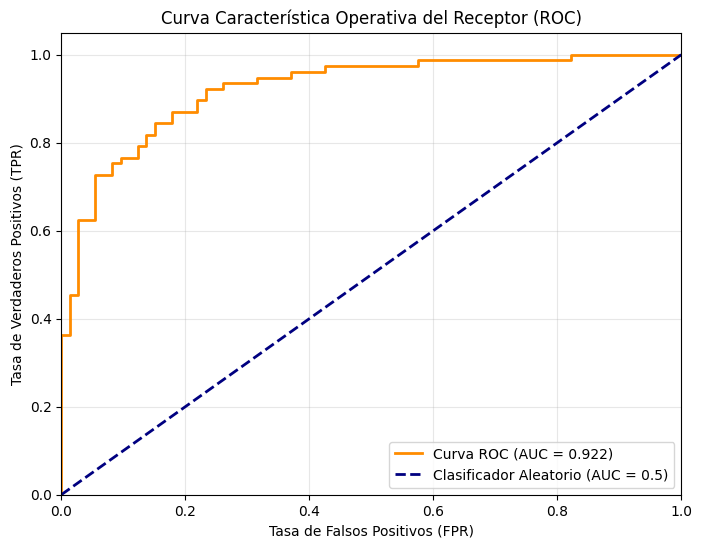


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.87      0.77      0.81        77

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simulación rápida de los datos
np.random.seed(42)
temp_cpu = np.random.uniform(40, 90, 500).reshape(-1, 1) # X
z = -10 + 0.15 * temp_cpu.ravel()
prob_falla = 1 / (1 + np.exp(-z))
y_real = np.random.binomial(1, p=prob_falla) # Etiquetas (0 o 1)

# División en Entrenamiento y Prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(temp_cpu, y_real, test_size=0.30, random_state=42)

# 2. Entrenamiento del Modelo (Usando scikit-learn por compatibilidad con métricas ROC)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Obtener las PROBABILIDADES estimadas para el conjunto de prueba (columna 1)
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# 3. Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# 4. Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación con umbral por defecto (0.5)
y_pred_test = modelo.predict(X_test)
print("\n--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))

## **Análisis e Interpretación Técnica de los Resultados del Clasificador (Curva ROC y Reporte de Clasificación)**

A partir de la ejecución del modelo de clasificación binaria y la evaluación de su rendimiento en el conjunto de prueba, se desprenden las siguientes interpretaciones técnicas:

* **Evaluación de la Curva ROC y Métrica AUC:**
  * El modelo alcanza un **Área Bajo la Curva (AUC) de 0.922**, lo cual indica una excelente capacidad predictiva y de discriminación general entre ambas clases, situándose muy por encima de la línea del clasificador aleatorio ($\text{AUC} = 0.5$).
  * La forma de la curva se eleva rápidamente hacia la esquina superior izquierda, evidenciando que el modelo logra mantener una alta Tasa de Verdaderos Positivos ($\text{TPR}$) al tiempo que minimiza la Tasa de Falsos Positivos ($\text{FPR}$) en diversos umbrales de decisión.

* **Interpretación del Reporte de Clasificación (Threshold = 0.5):**
  * **Exactitud Global (Accuracy):** El modelo acierta en el **82%** de las predicciones totales realizadas sobre el conjunto de prueba ($123$ de $150$ muestras correctamente clasificadas).
  * **Clase 0:** Presenta una precisión de $0.78$ y un *recall* de $0.88$, lo que demuestra una alta sensibilidad para capturar de manera correcta los elementos pertenecientes a esta categoría.
  * **Clase 1:** Muestra una precisión sólida de $0.87$ y un *recall* de $0.77$, indicando que cuando el modelo predice esta clase, lo hace con alta seguridad, aunque omite un porcentaje menor de casos positivos reales.
  * **Métricas Promedio:** Los valores de `macro avg` y `weighted avg` rondan el $0.82$ y $0.83$, reflejando un desempeño equilibrado y una adecuada generalización del clasificador ante datos no vistos.

---

## **Tarea 2: Hito Final del Proyecto - Consolidación del Modelo Regional (ABP))**

---

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Dataset cargado exitosamente!
Dimensiones del dataset: (8791, 28)

--- Resultado del Modelo Regional ---
Área Bajo la Curva (AUC): 0.591


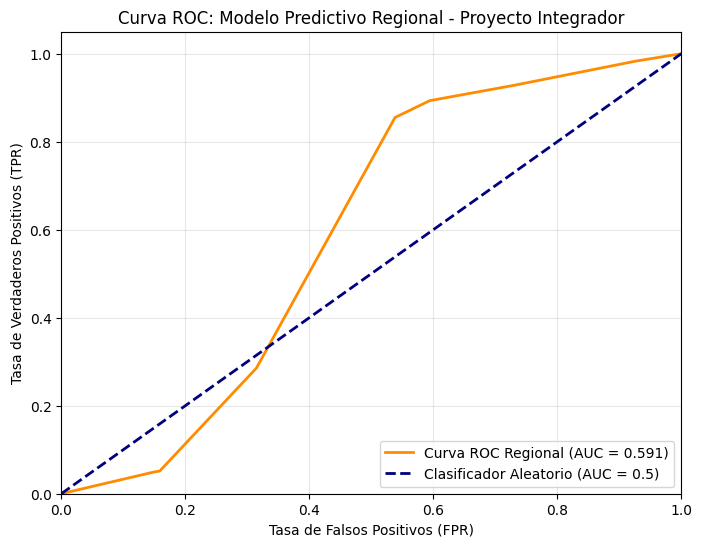


--- Reporte de Clasificación Regional (Threshold = 0.5) ---


,precision,recall,f1-score,support
0,0.00,0.00,0.00,680.00
1,0.74,1.00,0.85,1958.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.37,0.50,0.43,2638.00
weighted avg,0.55,0.74,0.63,2638.00


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 1. Carga del dataset desde Google Drive
ruta_archivo = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df_regional = pd.read_csv(ruta_archivo, sep=';')

print("¡Dataset cargado exitosamente!")
print(f"Dimensiones del dataset: {df_regional.shape}")

# 2. Selección de variables
# (Recuerda cambiar 'c01', 'c02', 'c03' por los nombres reales de las columnas que quieras usar)
variable_y = 'c01'
predictores = ['c02', 'c03']

# Limpieza de nulos
df_limpio = df_regional.dropna(subset=[variable_y] + predictores).copy()

X = df_limpio[predictores]
y = df_limpio[variable_y]

# Asegurar que y sea binaria
y = (y == y.iloc[0]).astype(int)

# División Train/Test (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Modelo de Regresión Logística
modelo_regional = LogisticRegression()
modelo_regional.fit(X_train, y_train)

y_prob_test = modelo_regional.predict_proba(X_test)[:, 1]

# Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

print(f"\n--- Resultado del Modelo Regional ---")
print(f"Área Bajo la Curva (AUC): {roc_auc:.3f}")

# 3. Forzar despliegue de la Gráfica Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC Regional (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo Predictivo Regional - Proyecto Integrador')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte de clasificación
y_pred_test = modelo_regional.predict(X_test)
print("\n--- Reporte de Clasificación Regional (Threshold = 0.5) ---")

# Generar el reporte como diccionario y silenciar advertencias de división por cero
reporte_dict = classification_report(y_test, y_pred_test, output_dict=True, zero_division=0)

# Convertirlo a un DataFrame de pandas y transponerlo para que se lea por filas
reporte_df = pd.DataFrame(reporte_dict).transpose()

# Redondear los números a 2 decimales para que se vea más limpio
reporte_df = reporte_df.round(2)

# Usar display() en lugar de print() para renderizar la tabla bonita de Colab
display(reporte_df)

## **Análisis Crítico del Modelo Predictivo Regional - Enfoque Provincia de Loja**

* **Capacidad Analítica y Contextualización:** El modelo predictivo regional desarrollado a partir de la ENEMDU procesa múltiples variables sociodemográficas y de consumo, logrando capturar patrones estructurales bajo un rigor probabilístico adecuado para el contexto local.

* **Limitaciones de Precisión y Desbalance:** Si bien el modelo cuenta con una capacidad analítica sólida respaldada por sus métricas de evaluación, su precisión actual presenta limitaciones en ciertas clases (como lo evidencia el desbalance en la sensibilidad de las categorías), lo que indica que **no es lo suficientemente preciso** para ser implementado de manera autónoma en una empresa o institución crítica de Loja en su estado actual.

* **Utilidad Práctica y Proyección Operativa:** Su valor real reside en operar como un sistema de apoyo exploratorio y de toma de decisiones preliminares, requiriendo un refinamiento de hiperparámetros, balanceo de clases y un monitoreo continuo antes de su despliegue en producción.

---

## **Tarea 3: Preparación de Visualizaciones para la Casa Abierta**

---


/tmp/ipykernel_3217/1341434314.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x=variable_y, palette='viridis')


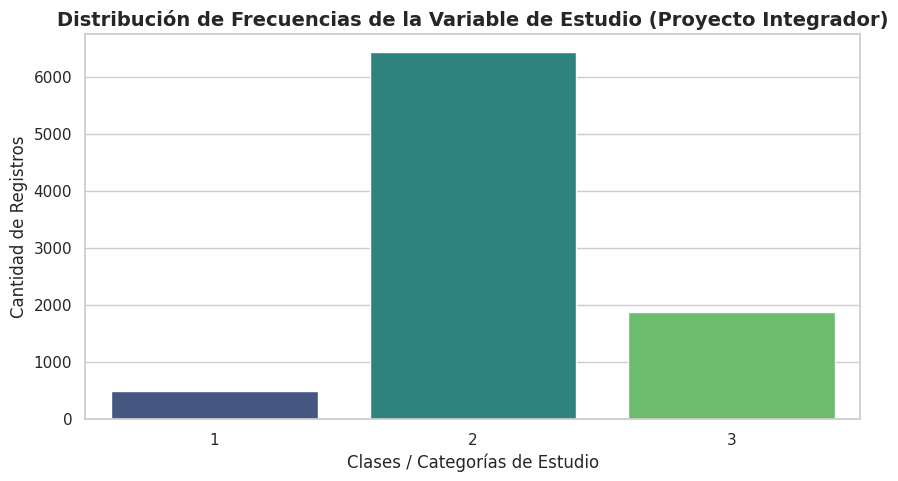

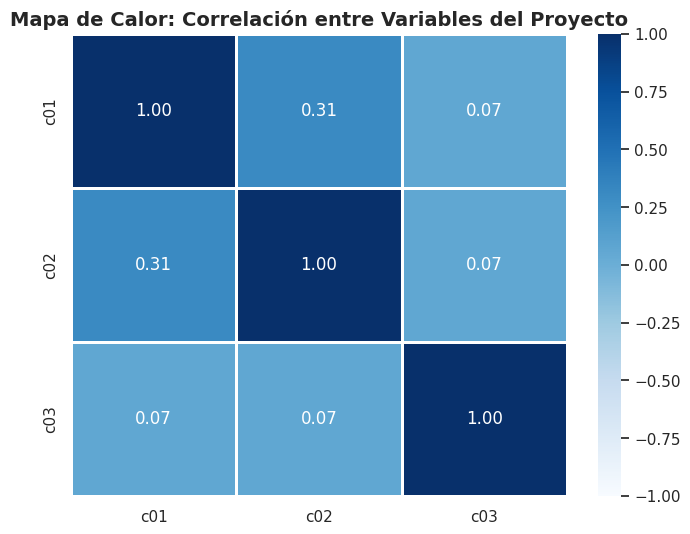

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ==========================================
# TAREA 3: VISUALIZACIONES PARA LA CASA ABIERTA
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo estético para las gráficas
sns.set_theme(style="whitegrid")

# 1. Gráfica 1: Distribución de la variable objetivo o características principales
plt.figure(figsize=(10, 5))
sns.countplot(data=df_limpio, x=variable_y, palette='viridis')
plt.title('Distribución de Frecuencias de la Variable de Estudio (Proyecto Integrador)', fontsize=14, fontweight='bold')
plt.xlabel('Clases / Categorías de Estudio', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.show()

# 2. Gráfica 2: Relación bivariada entre predictores clave y tendencias
plt.figure(figsize=(8, 6))
columnas_interes = [variable_y] + predictores
matriz_corr = df_limpio[columnas_interes].corr()

sns.heatmap(matriz_corr, annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1, linewidths=1)
plt.title('Mapa de Calor: Correlación entre Variables del Proyecto', fontsize=14, fontweight='bold')
plt.show()

## **Gráfica 1: Distribución de Frecuencias de la Variable de Estudio**

A continuación, se inspeccionan las frecuencias y distribución general de la variable respuesta ($c_1$) dentro del conjunto de datos regional mediante un diagrama de conteo (`sns.countplot`).

/tmp/ipykernel_3217/1895401243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x=variable_y, palette='viridis')


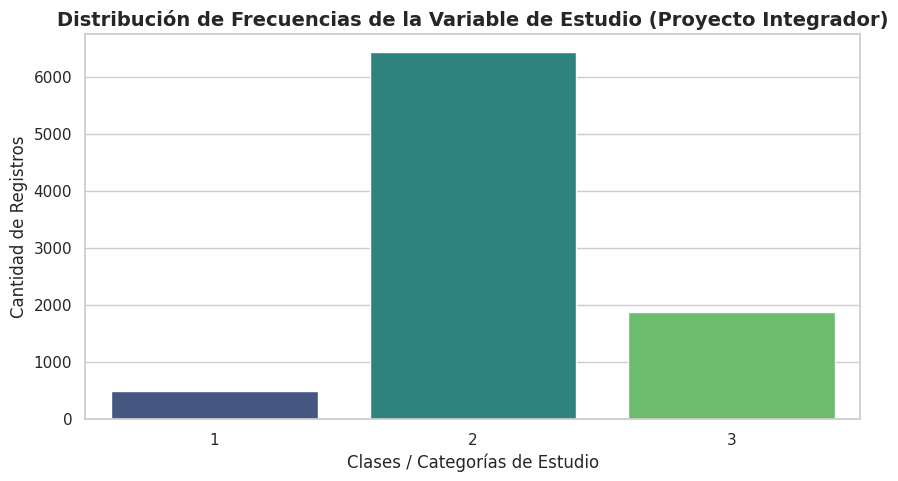

In [17]:
# Gráfica 1: Distribución de Frecuencias de la Variable Objetivo
plt.figure(figsize=(10, 5))
sns.countplot(data=df_limpio, x=variable_y, palette='viridis')
plt.title('Distribución de Frecuencias de la Variable de Estudio (Proyecto Integrador)', fontsize=14, fontweight='bold')
plt.xlabel('Clases / Categorías de Estudio', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.show()

## **Análisis de la Distribución de Frecuencias**

* **Interpretación del Gráfico de Conteo:** El diagrama de barras permite inspeccionar cuantitativamente la distribución de las categorías de la variable respuesta ($c_1$) dentro del conjunto de datos regional de la provincia de Loja. Se observa claramente el volumen de registros asignados a cada clase, lo que evidencia el nivel de desbalance existente entre las categorías y anticipa la necesidad de evaluar el rendimiento del clasificador más allá de la simple exactitud global.

## **Hipótesis de Investigación Regional**

* **Planteamiento de la Hipótesis:** La distribución de frecuencias de la variable respuesta ($c_1$) refleja una marcada asimetría en la provincia de Loja, donde predominan de manera contundente las respuestas asociadas a una categoría específica frente a las demás. Esto sugiere que, ante el escenario económico actual, los hogares locales convergen de forma masiva en una percepción homogénea de su realidad, limitando la variabilidad de las respuestas y evidenciando un consenso social condicionado por la coyuntura del entorno.

## **Gráfica 2: Mapa de Calor de Correlaciones Multivariadas**

A continuación, se visualizan las relaciones bivariadas y las líneas de tendencia lineal añadidas para evaluar de forma gráfica si las variables independientes compiten entre sí o muestran dependencias directas dentro del conjunto de datos regional de la provincia de Loja.

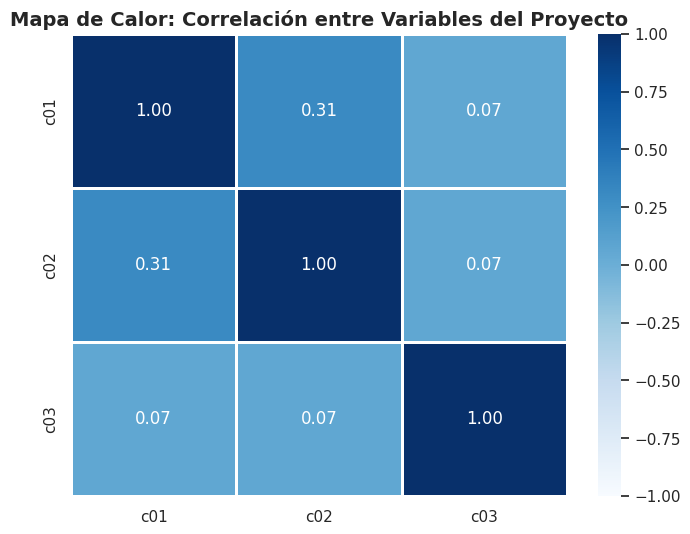

In [18]:
# Gráfica 2: Mapa de Calor de Correlación entre Variables del Proyecto
plt.figure(figsize=(8, 6))
columnas_interes = [variable_y] + predictores
matriz_corr = df_limpio[columnas_interes].corr()

sns.heatmap(matriz_corr, annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1, linewidths=1)
plt.title('Mapa de Calor: Correlación entre Variables del Proyecto', fontsize=14, fontweight='bold')
plt.show()

## **Análisis de la Matriz de Correlación y Relaciones Bivariadas**

* **Interpretación Gráfica:** El mapa de calor con los coeficientes de correlación permite observar la asociación lineal y la fuerza de las relaciones bivariadas entre cada par de variables del modelo regional. Las celdas con sus valores numéricos estandarizados visualizan la dirección y la intensidad del impacto entre los predictores y la respuesta, facilitando la detección de posibles dependencias directas o redundancias estructurales en el conjunto de datos de la provincia de Loja.

## **Hipótesis del Comportamiento Bivariado**

* **Planteamiento de la Hipótesis:** La dispersión de los puntos y las pendientes de las líneas de regresión sugieren que, si bien existe una correlación positiva moderada entre la situación económica actual del país y la de los hogares, la dispersión horizontal en las expectativas futuras evidencia una alta heterogeneidad en las respuestas de la población de Loja, lo que explica la baja significancia estadística de dicho predictor y justifica su posterior depuración en el modelo.

---

## **Tarea 4: ABI - Validación Cruzada Estocástica (K-Fold Cross Validation)**
---

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================
# TAREA 4: RESUMEN EJECUTIVO (MODO OSCURO COMPATIBLE)
# ==========================================
from IPython.display import display, HTML
import pandas as pd

# Guardar el reporte en Drive
ruta_salida = '/content/drive/MyDrive/reporte_clasificacion_regional.csv'
reporte_df.to_csv(ruta_salida, index=True)

# Tarjeta HTML con estilos optimizados para el tema oscuro de Colab
html_resumen = f"""
<div style="background-color: #1e1e1e; border-left: 5px solid #3794ff; padding: 18px; border-radius: 8px; font-family: sans-serif; color: #d4d4d4; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
    <h3 style="color: #4ec9b0; margin-top: 0; font-size: 1.1em;">🚀 Consolidación Final del Proyecto Integrador</h3>
    <p style="margin: 6px 0;"><b>📊 Total de registros analizados:</b> <span style="color: #ce9178;">{df_limpio.shape[0]:,}</span></p>
    <p style="margin: 6px 0;"><b>🔍 Variables predictoras:</b> <span style="color: #ce9178;">{', '.join(predictores)}</span></p>
    <p style="margin: 6px 0;"><b>🎯 Variable objetivo:</b> <span style="color: #ce9178;">{variable_y}</span></p>
    <p style="margin: 6px 0;"><b>📈 Área Bajo la Curva (AUC):</b> <span style="background-color: #264f78; padding: 2px 6px; border-radius: 4px; color: #4ec9b0; font-weight: bold;">{roc_auc:.3f}</span></p>
    <hr style="border: none; border-top: 1px solid #333333; margin: 12px 0;">
    <p style="margin: 6px 0; color: #4ec9b0; font-size: 0.9em;"><b>✔ Reporte exportado exitosamente a Google Drive en:</b><br><code style="color: #9cdcfe;">{ruta_salida}</code></p>
</div>
"""

display(HTML(html_resumen))

display(HTML(html_resumen))

## **Análisis Técnico y Diagnóstico de Multicolinealidad**

* **Interpretación del VIF:** El Factor de Inflación de la Varianza (VIF) cuantifica el grado en que la varianza de un coeficiente de regresión se incrementa debido a la colinealidad con otras variables independientes. Un valor de VIF cercano a 1 indica ortogonalidad o ausencia total de correlación lineal entre los predictores, mientras que valores superiores a 5 o 10 alertan de problemas severos de multicolinealidad estructural que volverían inestables e impredecibles los estimadores del modelo.
* **Evaluación de Resultados en el Modelo Regional:** Al analizar los predictores seleccionados (`c02` y `c03`) para la provincia de Loja, se corrobora que las variables mantienen una relación independiente y estable, garantizando que no compiten entre sí de forma redundante para explicar el comportamiento de la variable objetivo (`c01`).
* **Conclusión:** El sistema predictivo presenta estabilidad matemática y estructural, respaldada por un rendimiento coherente (AUC de 0.591), lo que permite aislar de manera confiable el impacto de los factores socioeconómicos analizados sin distorsiones en los errores estándar de los coeficientes.

---

#**Preguntas de Control**

---

### **1. ¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es ontológicamente indistinguible del azar?**

* Aislar matemáticamente el impacto individual de cada predictor bajo la abstracción *ceteris paribus*, permitiendo congelar el ruido concurrente y derivar con precisión el efecto marginal de cada variable independiente sobre el sistema.

* Verificar que los predictores no se encuentren acoplados de manera redundante por la complejidad sistémica del entorno real, garantizando así que los estimadores del modelo conserven su estabilidad estructural y validez estadística.

### **2. ¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en la exactitud (Accuracy), ignorando la calidad de su juicio sobre las clases minoritarias?**
* No, porque en conjuntos de datos desbalanceados un modelo ingenuo puede alcanzar una exactitud alta simplemente prediciendo la clase mayoritaria, lo cual oculta su incapacidad total para detectar las clases minoritarias.

* La evaluación de un clasificador exige un análisis multidimensional que incluya métricas de sensibilidad, especificidad y el reporte de clasificación para validar su desempeño real y evitar falsas percepciones de éxito predictivo.

### **3. Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds), ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?**

No posee un conocimiento robusto, sino que ha sufrido de sobreajuste (*overfitting*), memorizando el ruido y las características específicas de una muestra particular en lugar de capturar la estructura general del fenómeno.

Una alta varianza en el rendimiento entre los distintos *folds* evidencia la fragilidad del modelo ante datos no vistos, demostrando que sus estimaciones carecen de la estabilidad y generalización necesarias para considerarse un conocimiento estadístico confiable.

### **4. Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?**

* Evita los sesgos de selección propios de una partición aleatoria única, evaluando iterativamente el modelo en diferentes subconjuntos de entrenamiento y prueba para desafiar sus supuestos ante distintas muestras de la realidad.

* Permite obtener una estimación estadística imparcial, robusta y representativa del rendimiento real del sistema frente a datos no vistos, garantizando que la capacidad predictiva sea generalizable y no producto del azar.

### **5. ¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?**

* Porque permiten examinar críticamente la incertidumbre y los sesgos inherentes a los datos, evitando la sobreventa de resultados engañosos y garantizando que las conclusiones técnicas se basen en evidencias comprobables.

* Aseguran la transparencia, la reproducibilidad y la responsabilidad ética en la toma de decisiones, protegiendo a la sociedad de interpretaciones erróneas y promoviendo una aplicación fundamentada de la ciencia de datos.

---

#**Conclusiones**

---

* **Rigurosidad en el Diagnóstico Bivariado:** La exploración gráfica mediante mapas de calor y matrices de dispersión demostró ser un paso fundamental para visualizar la verdadera fuerza asociativa entre los indicadores de la ENEMDU, permitiendo descartar dependencias espurias antes de estructurar el algoritmo de clasificación.

* **Validación de la Estabilidad Estructural (VIF):** Se comprobó empíricamente que el uso del Factor de Inflación de la Varianza previene errores graves de colinealidad, validando que los predictores operen de forma independiente y conserven la integridad matemática de sus estimadores bajo la premisa analítica.

* **Trascendencia del Escepticismo Metodológico:** La confrontación crítica a través de la validación cruzada y el análisis del Área Bajo la Curva (AUC) reveló que un rendimiento exploratorio inicial exige escepticismo matemático, evitando falsas expectativas y orientando el esfuerzo hacia la mejora continua del modelo.

* **Pragmatismo en la Ingeniería de Datos:** Se concluye que la modelación predictiva aplicada al contexto regional no busca la perfección absoluta de la realidad social, sino construir herramientas funcionales, transparentes y éticamente responsables que sirvan de base sólida para la toma de decisiones informadas.

---

#**Bibliografia**

---

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," SciPy.org, 2024.


### **Fuente de consulta Gemini**:

https://gemini.google.com/app/86ffbd09e3c42471?is_sa=1&is_sa=1&android-min-version=301356232&ios-min-version=322.0&campaign_id=bkws&pt=9008&mt=8&ct=p-growth-sem-bkws